# 02 · Does the convenience yield forecast S&P 500 volatility?

**Question.** Does the 1-year convenience yield (CY) improve out-of-sample forecasts of S&P 500 realized volatility over the next 20 trading days, beyond what VIX and recent realized volatility already give?

**Setup** (fixed in `config.py` before any results were seen):

- **Target:** `RV_fwd_t = sqrt(252/20 · Σ_{i=1..20} r²_{t+i})`, with `r` the daily SPX log return, annualized, in %. The primary target is `log RV_fwd`; levels are a robustness check.
- **Baseline** (information at the close of t): VIX plus HAR realized-vol components over 1, 5 and 22 days (Corsi 2009). These enter in logs for the log target and in levels for the level target.
- **CY features:** the 1y CY level (bp), its 5-day change, a trailing 252-day z-score, and the slope (1y − 3m). Each is added to the baseline on its own, then all four together. Robustness variants use a different Treasury leg (FRED `DGS1`) and a control for the 1y yield level.
- **Protocol:** expanding-window OLS, refit on the first trading day of each month. **Embargo:** at forecast date t, the model trains only on rows s ≤ t − 20 trading days, whose 20-day targets are fully observed by t. The tests verify that perturbing any data after t leaves every forecast at or before t unchanged.
- **Evaluation:** OOS R² = 1 − SSE_model / SSE_benchmark. The **Clark–West** test for nested models uses Newey–West standard errors with 20 lags (the targets overlap) and a one-sided p-value. OOS starts on 2008-01-02, and on 2010-01-04 as a robustness check.

**Sample limit.** Box-rate data exist only from **2005-01 to 2020-07**. The model sample starts 2005-07-01, once the z-score has 126 observations. There is nothing after mid-2020.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter, LogLocator, NullFormatter

from stress_signal.config import EPISODE_LOOKBACK, EPISODES, OOS_STARTS, RESULTS
from stress_signal.evaluation import cumulative_dsse, format_metrics, oos_r2_by_period
from stress_signal.features import MODEL_LABELS
from stress_signal.plotting import AXIS, INK, INK_2, MUTED, SERIES, apply_style, shade_episodes, source_note

apply_style()
pd.options.display.float_format = "{:.3f}".format

metrics = pd.read_csv(RESULTS / "metrics.csv")
episodes = pd.read_csv(RESULTS / "episodes.csv")
insample = pd.read_csv(RESULTS / "insample.csv")
timing = pd.read_csv(RESULTS / "timing.csv")
fc = {
    (kind, start): pd.read_csv(RESULTS / f"forecasts_{kind}_{start:%Y%m%d}.csv", index_col="date", parse_dates=True)
    for kind in ("log", "level") for start in OOS_STARTS
}

## Out-of-sample results, log target

The first row compares the baseline with the historical mean. The other rows compare each CY-augmented model with its nested benchmark: the baseline, or the baseline plus the 1y yield for the two rate-control rows.

In [2]:
format_metrics(metrics, "log", MODEL_LABELS)

OOS start                               2008-01-02              2010-01-04  \
                                        OOS R² (%)   CW t  CW p OOS R² (%)   
Baseline (VIX + HAR) vs historical mean     58.290  6.509 0.000     48.334   
+ CY 1y level                                2.361  3.225 0.001     -0.757   
+ 5-day change in CY                        -0.067  0.605 0.273     -0.273   
+ CY 252-day z-score                        -0.386  0.872 0.192     -1.167   
+ CY slope (1y - 3m)                        -2.442 -0.704 0.759     -1.258   
+ all four CY features                      -2.179  2.018 0.022     -3.273   
+ CY level, FRED DGS1 leg                    2.998  3.223 0.001      0.281   
+ CY level, with 1y yield control            1.760  3.100 0.001     -2.080   
+ all CY, with 1y yield control             -2.733  1.791 0.037     -4.916   

OOS start                                             
                                          CW t  CW p  
Baseline (VIX + HAR) vs historical mean  6.915 0.000  
+ CY 1y level                            1.477 0.070  
+ 5-day change in CY                    -0.228 0.590  
+ CY 252-day z-score                     0.263 0.396  
+ CY slope (1y - 3m)                    -2.591 0.995  
+ all four CY features                   0.685 0.247  
+ CY level, FRED DGS1 leg                1.795 0.036  
+ CY level, with 1y yield control        1.094 0.137  
+ all CY, with 1y yield control          0.012 0.495

- The **baseline is strong**: it explains 58% of the out-of-sample variance of log RV over 2008–2020, and 48% over 2010–2020, relative to the historical mean.
- **CY level** is the only feature that helps. With the OOS window starting in 2008, it improves the MSE by 2.4% (Clark–West t = 3.2, p < 0.001). With the window starting in 2010, the gain disappears: OOS R² is −0.8% (CW p = 0.07).
- The **5-day change, z-score and slope** do not help in either window. The slope makes forecasts worse.
- **All four together** has a negative OOS R² in both windows. The 2008 CW test still rejects (p = 0.02). This is not a contradiction: CW asks whether the extra coefficients are non-zero in population and corrects for the noise of estimating them. A positive CW statistic with a negative OOS R² means some information is present, but four extra parameters cost more than they return in a sample of this size.
- **Robustness:** the version with the FRED `DGS1` Treasury leg behaves like the main CY level, and is slightly stronger: +3.0% from 2008, and +0.3% from 2010 (CW p = 0.04). With the 1y-yield control the 2008 gain shrinks to 1.8%, and from 2010 it turns negative.

There are 16 CY comparisons per target (8 specifications × 2 windows). Every rejection at 5% involves the CY level, and all but one (the FRED-leg variant from 2010, with a tiny R² gain) need 2008–09 in the evaluation window.

## Out-of-sample results, level target

In [3]:
format_metrics(metrics, "level", MODEL_LABELS)

OOS start                               2008-01-02              2010-01-04  \
                                        OOS R² (%)   CW t  CW p OOS R² (%)   
Baseline (VIX + HAR) vs historical mean     50.619  3.590 0.000     42.496   
+ CY 1y level                                1.699  2.331 0.010     -0.809   
+ 5-day change in CY                        -0.523 -0.220 0.587     -1.232   
+ CY 252-day z-score                        -0.241  0.683 0.247     -0.717   
+ CY slope (1y - 3m)                        -9.415 -0.840 0.800     -1.153   
+ all four CY features                      -5.678  1.064 0.144     -4.219   
+ CY level, FRED DGS1 leg                    3.189  2.840 0.002      0.401   
+ CY level, with 1y yield control            1.945  2.667 0.004     -2.222   
+ all CY, with 1y yield control             -4.861  1.301 0.097     -5.916   

OOS start                                             
                                          CW t  CW p  
Baseline (VIX + HAR) vs historical mean  3.275 0.001  
+ CY 1y level                            1.425 0.077  
+ 5-day change in CY                    -0.892 0.814  
+ CY 252-day z-score                     0.339 0.367  
+ CY slope (1y - 3m)                    -2.771 0.997  
+ all four CY features                   0.718 0.236  
+ CY level, FRED DGS1 leg                1.790 0.037  
+ CY level, with 1y yield control        1.077 0.141  
+ all CY, with 1y yield control          0.254 0.400

The level target gives the same ranking. The CY level adds 1.7% from 2008 (CW p = 0.01) and −0.8% from 2010. The other features add nothing.

## Where the gains come from

The model is refit on the same schedule regardless of the OOS start, so the forecasts after 2010-01-04 are identical in both runs. The two OOS windows differ only in whether 2008–09 is scored. Each curve below is the running sum of `e²_baseline − e²_model` for the log target. A rising curve means the CY model is beating the baseline.

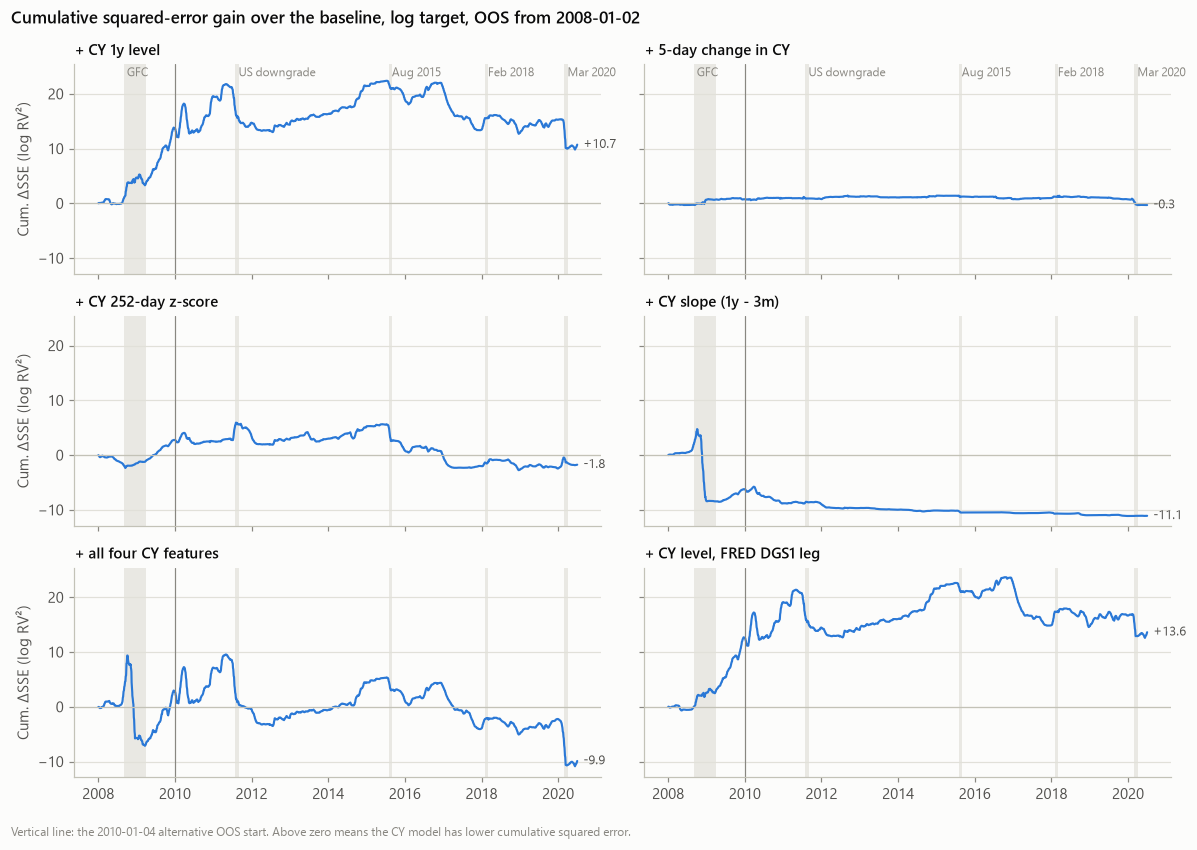

In [4]:
f = fc[("log", OOS_STARTS[0])]
panels = ["cy_level", "cy_d5", "cy_z", "cy_slope", "cy_all", "cy_level_fred"]
fig, axes = plt.subplots(3, 2, figsize=(11, 7.5), sharex=True, sharey=True)
for ax, model in zip(axes.flat, panels):
    d = cumulative_dsse(f, "baseline", model)
    ax.plot(d.index, d, color=SERIES[0], lw=1.4)
    ax.axhline(0, color=AXIS, lw=0.8)
    ax.axvline(OOS_STARTS[1], color=MUTED, lw=0.8)
    shade_episodes(ax, label=ax in axes[0])
    ax.set_title(MODEL_LABELS[model], fontsize=10)
    ax.annotate(f"{d.iloc[-1]:+.1f}", xy=(d.index[-1], d.iloc[-1]), xytext=(4, 0),
                textcoords="offset points", va="center", fontsize=8.5, color=INK_2)
for ax in axes[:, 0]:
    ax.set_ylabel("Cum. ΔSSE (log RV²)")
fig.suptitle("Cumulative squared-error gain over the baseline, log target, OOS from 2008-01-02",
             x=0.01, ha="left", fontsize=11, fontweight="semibold")
fig.tight_layout()
source_note(fig, "Vertical line: the 2010-01-04 alternative OOS start. Above zero means the CY model has lower cumulative squared error.")
plt.show()

In [5]:
periods = {"2008–2009": ("2008", "2009"), "2010–2019": ("2010", "2019"), "2020 H1": ("2020", "2020")}
by_period = oos_r2_by_period(f, "baseline", panels, periods)
by_period.index = [MODEL_LABELS[m] for m in by_period.index]
by_period.rename_axis("OOS R² vs baseline (%)")

,2008–2009,2010–2019,2020 H1
OOS R² vs baseline (%),,,
+ CY 1y level,19.888,0.508,-6.944
+ 5-day change in CY,1.089,-0.005,-1.583
+ CY 252-day z-score,4.005,-1.626,1.075
+ CY slope (1y - 3m),-9.096,-1.525,0.048
+ all four CY features,3.970,-1.547,-11.715
"+ CY level, FRED DGS1 leg",18.273,1.283,-4.624


Almost all of the CY-level gain is earned in **2008–2009**, at about 20%. The curve keeps climbing through 2009 and 2010 as volatility comes down from its crisis peak. Over 2010–2019 the net gain is roughly zero (+0.5%), because the 2010 gains are given back in 2011 and 2017. In the first half of 2020 it is clearly negative: the CY collapsed, and briefly turned negative, just as volatility exploded, so the model pointed the wrong way. The other features give no lasting gain at any point.

## Stress episodes

Forecasts from the 2008-start run, log target, shown in levels on a log scale. Each point is plotted at its forecast date t. The black line is the volatility realized over t+1..t+20. Each window starts 63 trading days before the episode (shaded).

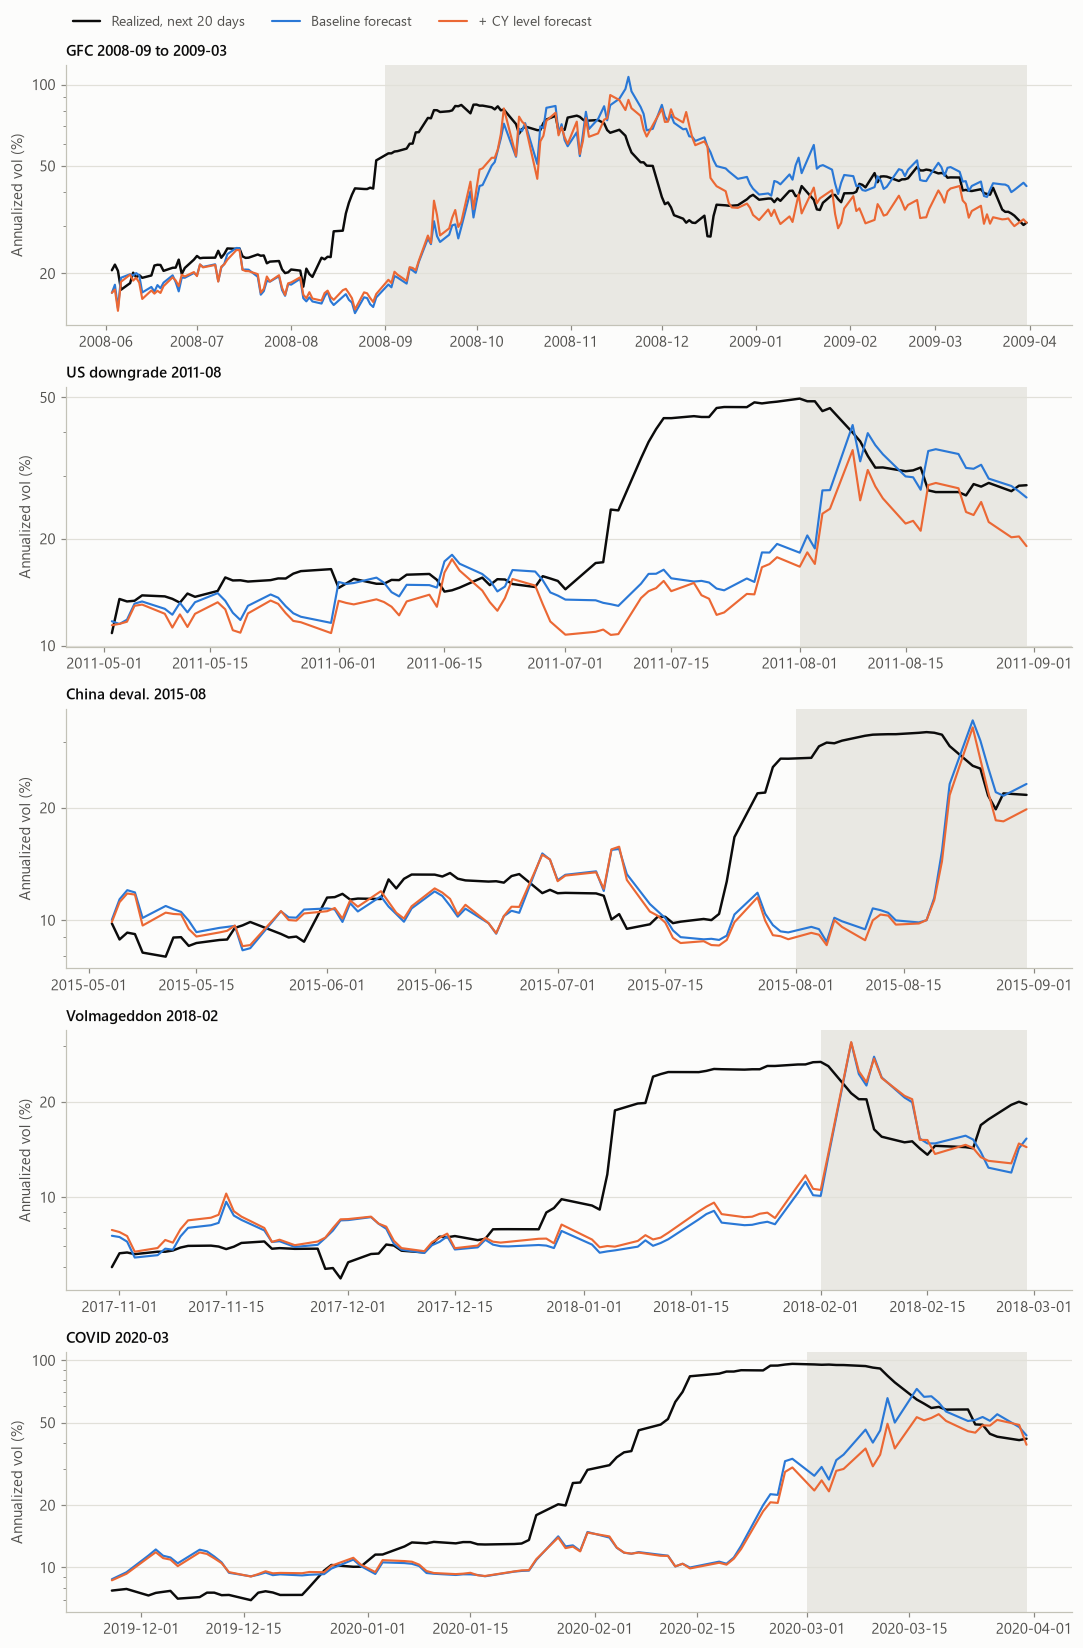

In [6]:
f = fc[("log", OOS_STARTS[0])]
fig, axes = plt.subplots(len(EPISODES), 1, figsize=(10, 3.0 * len(EPISODES)))
lines = {"y": ("Realized, next 20 days", INK), "baseline": ("Baseline forecast", SERIES[0]), "cy_level": ("+ CY level forecast", SERIES[1])}
for ax, (name, (start, end)) in zip(axes, EPISODES.items()):
    i0 = max(f.index.searchsorted(start) - EPISODE_LOOKBACK, 0)
    w = f.iloc[i0 : f.index.searchsorted(end, side="right")]
    for col, (label, color) in lines.items():
        ax.plot(w.index, np.exp(w[col]), color=color, lw=1.6 if col == "y" else 1.4, label=label)
    ax.axvspan(start, end, color="#e9e8e3", lw=0, zorder=0)
    ax.set_yscale("log")
    ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1.0, 2.0, 5.0)))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.set_ylabel("Annualized vol (%)")
    ax.set_title(name, fontsize=10)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncols=3, loc="upper left", bbox_to_anchor=(0.06, 1.0))
fig.tight_layout(rect=(0, 0, 1, 0.985))
plt.show()

In [7]:
ep = episodes[(episodes["target"] == "log") & (episodes["oos_start"] == str(OOS_STARTS[0].date()))]
ep.pivot(index="episode", columns="model", values=["mean_error", "rmse"]).reindex(list(EPISODES)).rename_axis(
    "log target, error = realized − forecast")

mean_error                     rmse  \
model                                     baseline cy_all cy_level baseline   
log target, error = realized − forecast                                       
GFC 2008-09 to 2009-03                       0.040  0.062    0.161    0.511   
US downgrade 2011-08                         0.115  0.373    0.348    0.395   
China deval. 2015-08                         0.700  0.781    0.762    0.900   
Volmageddon 2018-02                          0.038  0.070    0.038    0.385   
COVID 2020-03                                0.350  0.519    0.515    0.628   

                                                         
model                                   cy_all cy_level  
log target, error = realized − forecast                  
GFC 2008-09 to 2009-03                   0.573    0.491  
US downgrade 2011-08                     0.493    0.477  
China deval. 2015-08                     0.942    0.924  
Volmageddon 2018-02                      0.372    0.374  
COVID 2020-03                            0.746    0.749

In every episode, both models **under-forecast** volatility on average (mean error > 0). Neither anticipates the jump. Adding the CY level lowers the RMSE only slightly in the GFC window (0.49 vs 0.51) and in February 2018 (0.37 vs 0.39). It raises the RMSE in August 2011, August 2015 and March 2020, where the CY was at or below its usual level going into the shock.

### Did the CY move before or after VIX?

Each window starts 63 trading days before the episode. The table reports peak dates and the first date each series' trailing 252-day z-score exceeds 2. Leads are in trading days; a positive lead means CY moved first.

In [8]:
timing

,episode,cy_peak_date,cy_peak_bp,vix_peak_date,vix_peak,peak_lead_days,cy_z_cross_date,vix_z_cross_date,cross_lead_days
0,GFC 2008-09 to 2009-03,2008-10-10,149.979,2008-11-20,80.860,29,2008-09-17,2008-09-15,-2.000
1,US downgrade 2011-08,2011-07-11,35.797,2011-08-08,48.000,20,2011-06-15,2011-08-04,35.000
2,China deval. 2015-08,2015-07-14,38.052,2015-08-24,40.740,29,NaN,2015-08-21,NaN
3,Volmageddon 2018-02,2018-02-26,68.024,2018-02-05,37.320,-14,2018-02-06,2018-01-29,-6.000
4,COVID 2020-03,2020-03-30,75.210,2020-03-16,82.690,-10,2019-12-13,2020-02-24,47.000


There is no consistent lead. The CY peaks before VIX in 2008, 2011 and 2015. But in 2011 and 2015 those peaks (36–38 bp) are ordinary values near the sample mean, not stress readings: the CY z-score never crosses 2 in the 2015 window. In 2018 and 2020 the CY peaks after VIX. The CY z-score crosses 2 before VIX in 2011 and 2020, but the 2020 crossing is in mid-December 2019, months before the COVID shock. That is not a usable warning. In 2008 the two z-scores cross within two days of each other.

## In-sample (full period, descriptive only)

OLS on the full model sample, with Newey–West standard errors (20 lags). These estimates are not forecasts.

In [9]:
insample.pivot_table(index=["target", "spec", "variable"], values=["coef", "hac_t", "hac_p", "r2", "r2_baseline"], sort=False)

coef  hac_t  hac_p    r2  r2_baseline
target spec     variable                                           
log    cy_level cy_1y_bp     0.003  2.689  0.007 0.595        0.582
       cy_d5    d5_cy_1y_bp  0.001  0.629  0.529 0.582        0.582
       cy_z     z_cy_1y      0.021  1.398  0.162 0.585        0.582
       cy_slope slope_cy_bp -0.000 -0.212  0.832 0.582        0.582
       cy_all   cy_1y_bp     0.004  2.244  0.025 0.595        0.582
                d5_cy_1y_bp -0.000 -0.193  0.847 0.595        0.582
                z_cy_1y     -0.008 -0.336  0.737 0.595        0.582
                slope_cy_bp -0.000 -0.161  0.872 0.595        0.582
level  cy_level cy_1y_bp     0.084  1.912  0.056 0.574        0.559
       cy_d5    d5_cy_1y_bp -0.009 -0.133  0.894 0.559        0.559
       cy_z     z_cy_1y      0.465  1.374  0.169 0.562        0.559
       cy_slope slope_cy_bp -0.003 -0.140  0.889 0.559        0.559
       cy_all   cy_1y_bp     0.093  1.676  0.094 0.575        0.559
                d5_cy_1y_bp -0.044 -0.644  0.519 0.575        0.559
                z_cy_1y     -0.159 -0.280  0.779 0.575        0.559
                slope_cy_bp -0.002 -0.081  0.935 0.575        0.559

In sample, the CY level is significant for log RV (HAC t ≈ 2.7). The coefficient is about 0.0034 per bp, so a 10 bp higher CY goes with roughly 3.4% higher expected future volatility. It raises R² from 0.582 to 0.595. No other CY feature is significant.

## Conclusion and limitations

- Over 2008–2020, the 1y convenience yield adds a small, statistically significant amount of out-of-sample information about next-month S&P 500 volatility beyond VIX and HAR. That result comes almost entirely from 2008–2009. From 2010 onward the gain is roughly zero, and it is negative in early 2020. Changes, z-scores and the term-structure slope add nothing.
- **Sample.** The data end in July 2020. The result rests on essentially one crisis, and the 2022–2025 rate-hiking period is untested. Extending the sample needs raw SPX option quotes (e.g. via WRDS) to rebuild box rates.
- **What the box rate measures.** A box spread is a synthetic loan through SPX options. Its rate includes option-market frictions: bid–ask spreads, margin and balance-sheet costs, and the quote-selection choices in the source paper. So the CY mixes Treasury specialness with derivatives-market funding conditions. In March 2020 these moved in opposite directions.
- **Rate level.** The CY–rate relationship is unstable (notebook 01). A 1y-yield control weakens the result.
- **No causal claim.** These are predictive regressions. A higher CY in 2008–09 coincided with, and slightly helped predict, high volatility. It does not show that safety demand causes volatility.
- **Testing.** 16 CY comparisons were run per target. The significant ones all rely on the CY level, and nearly all of them on the 2008–09 evaluation window. No correction for multiple comparisons is applied.